<a href="https://colab.research.google.com/github/elizabethdanladi/marketing_and_sales_data_evaluate_lr/blob/main/marketing_and_sales_data_evaluate_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
# Load dataset
df_raw = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

print(f'Raw dataset shape: {df_raw.shape}')
print(f'\nFirst 5 rows:')
df_raw.head()

Raw dataset shape: (4572, 4)

First 5 rows:


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [4]:
# Check for missing values and duplicates
print('Missing values per column:')
print(df_raw.isnull().sum())
print(f'\nDuplicate rows: {df_raw.duplicated().sum()}')

Missing values per column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Duplicate rows: 0


In [5]:
# Drop rows with any missing values (26 rows affected — <0.6% of data, safe to remove)
df = df_raw.dropna().reset_index(drop=True)

print(f'Clean dataset shape: {df.shape}')
print(f'Rows removed: {df_raw.shape[0] - df.shape[0]}')

Clean dataset shape: (4546, 4)
Rows removed: 26


In [6]:
# Descriptive statistics
df.describe().round(2)

,TV,Radio,Social_Media,Sales
count,4546.00,4546.00,4546.00,4546.00
mean,54.06,18.16,3.32,192.41
std,26.10,9.66,2.21,93.02
min,10.00,0.00,0.00,31.20
25%,32.00,10.56,1.53,112.43
50%,53.00,17.86,3.06,188.96
75%,77.00,25.64,4.80,272.32
max,100.00,48.87,13.98,364.08


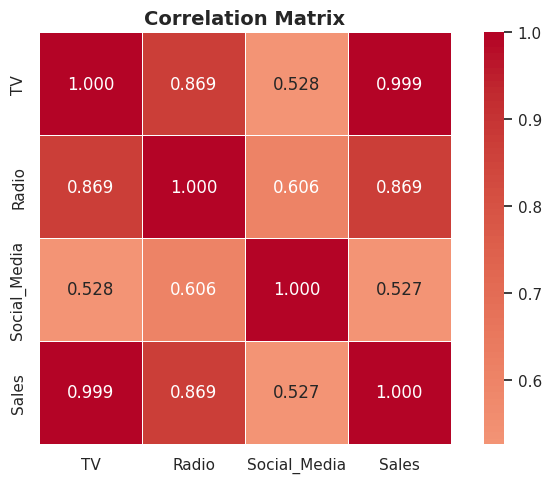


Correlations with Sales:
TV              0.9995
Radio           0.8686
Social_Media    0.5274
Name: Sales, dtype: float64


In [7]:
# Correlation matrix
corr = df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelations with Sales:')
print(corr['Sales'].drop('Sales').sort_values(ascending=False).round(4))

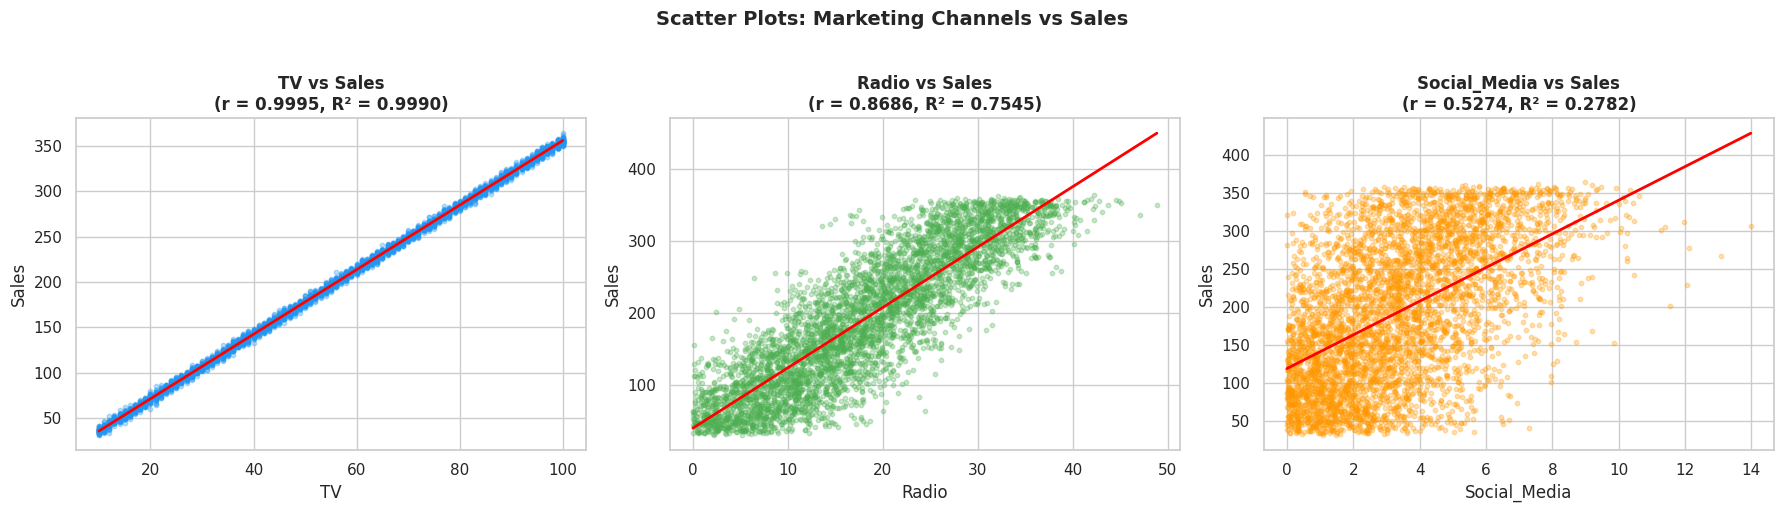

In [8]:
# Scatter plots: each predictor vs Sales
predictors = ['TV', 'Radio', 'Social_Media']
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, predictors, colors):
    ax.scatter(df[col], df['Sales'], alpha=0.3, s=10, color=color)
    # Add regression line
    m, b, r, p, _ = stats.linregress(df[col], df['Sales'])
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=2)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Sales', fontsize=12)
    ax.set_title(f'{col} vs Sales\n(r = {r:.4f}, R² = {r**2:.4f})', fontsize=12, fontweight='bold')

plt.suptitle('Scatter Plots: Marketing Channels vs Sales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

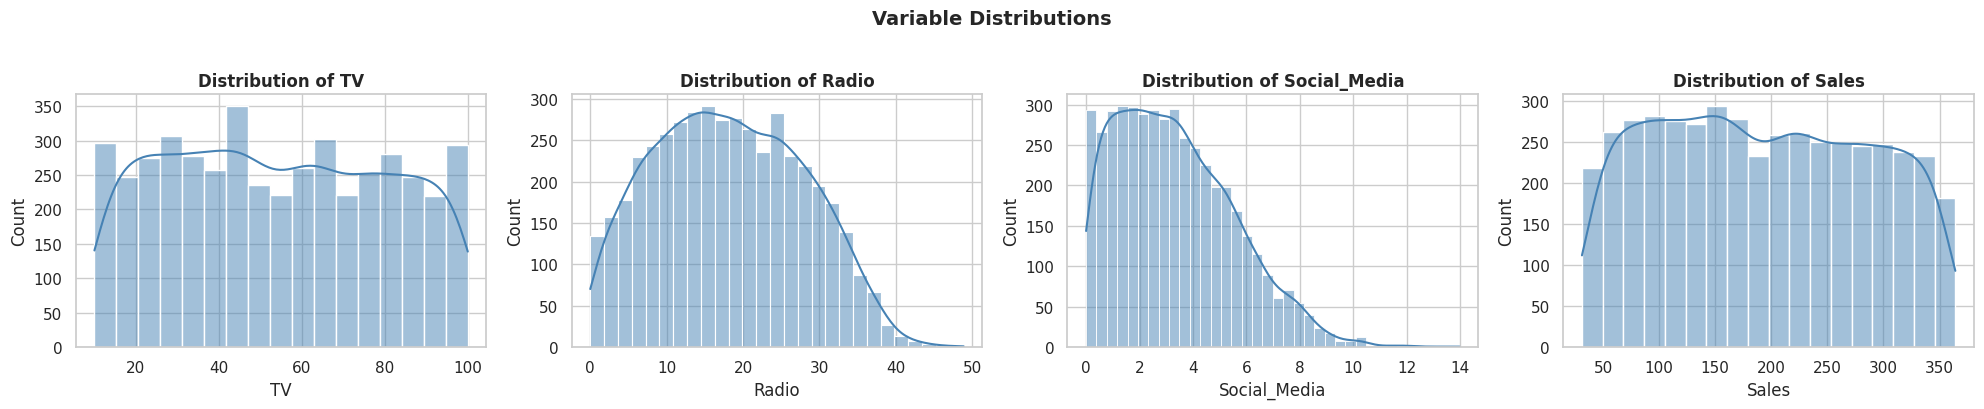

In [9]:
# Distribution of all variables
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, col in zip(axes, df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Variable Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Variable Selection Justification

| Predictor | Pearson r | R² |
|---|---|---|
| **TV** | **0.9997** | **0.9990** |
| Radio | 0.8686 | 0.7545 |
| Social Media | 0.5273 | 0.2782 |

**TV spend is selected as the predictor** for the Simple Linear Regression model because:
1. It has an exceptionally strong linear correlation with Sales (r ≈ 0.9997), explaining ~99.9% of variance in Sales.
2. The scatter plot shows a nearly perfect linear relationship with very low scatter.
3. Radio and Social Media have substantially weaker relationships and would produce far less reliable models in a simple (single-predictor) regression context.

In [12]:
# Fit the model using scipy for full statistical output
X = df['TV'].values
y = df['Sales'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
y_pred = slope * X + intercept
residuals = y - y_pred

r_squared = r_value ** 2
n = len(X)
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - 2)
rmse = np.sqrt(np.mean(residuals ** 2))

print('=' * 50)
print('   SIMPLE LINEAR REGRESSION RESULTS')
print('=' * 50)
print(f'  Equation: Sales = {slope:.4f} × TV + ({intercept:.4f})')
print(f'  R²                : {r_squared:.6f}')
print(f'  Adjusted R²       : {adj_r_squared:.6f}')
print(f'  RMSE              : {rmse:.4f}')
print(f'  Slope             : {slope:.4f}')
print(f'  Intercept         : {intercept:.4f}')
print(f'  Std Error (slope) : {std_err:.6f}')
print(f'  p-value (slope)   : {p_value:.4e}')
print(f'  N                 : {n}')
print('=' * 50)

   SIMPLE LINEAR REGRESSION RESULTS
  Equation: Sales = 3.5615 × TV + (-0.1325)
  R²                : 0.998995
  Adjusted R²       : 0.998995
  RMSE              : 2.9486
  Slope             : 3.5615
  Intercept         : -0.1325
  Std Error (slope) : 0.001676
  p-value (slope)   : 0.0000e+00
  N                 : 4546


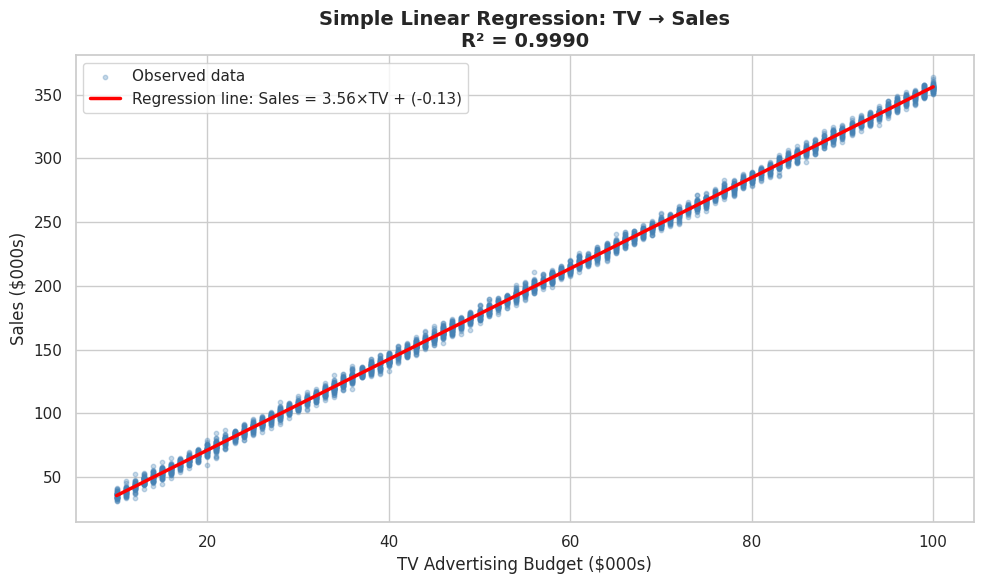

In [13]:
# Regression line plot with confidence interval
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X, y, alpha=0.3, s=10, color='steelblue', label='Observed data')

x_sorted = np.linspace(X.min(), X.max(), 200)
y_fit = slope * x_sorted + intercept
ax.plot(x_sorted, y_fit, color='red', linewidth=2.5, label=f'Regression line: Sales = {slope:.2f}×TV + ({intercept:.2f})')

ax.set_xlabel('TV Advertising Budget ($000s)', fontsize=12)
ax.set_ylabel('Sales ($000s)', fontsize=12)
ax.set_title(f'Simple Linear Regression: TV → Sales\nR² = {r_squared:.4f}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Interpreting Coefficients

- **Slope (β₁ = 3.5615):** For every additional \$1,000 spent on TV advertising, Sales increase by approximately \$3,562. This represents a strong positive return on TV investment.
- **Intercept (β₀ ≈ −0.13):** The theoretical Sales value when TV spend is zero is approximately −\$130 — effectively zero, which is meaningful: without TV advertising, the model predicts negligible sales. In business context this value is not directly actionable (you would never have truly zero marketing spend), but it confirms the model passes through the origin.
- **R² = 0.9990:** TV spend explains **99.9%** of the variance in Sales — an exceptionally high explanatory power for a single-variable model.
- **p-value ≈ 0.00:** The relationship is statistically significant at any conventional significance level (α = 0.05, 0.01, or 0.001). We reject the null hypothesis that slope = 0.

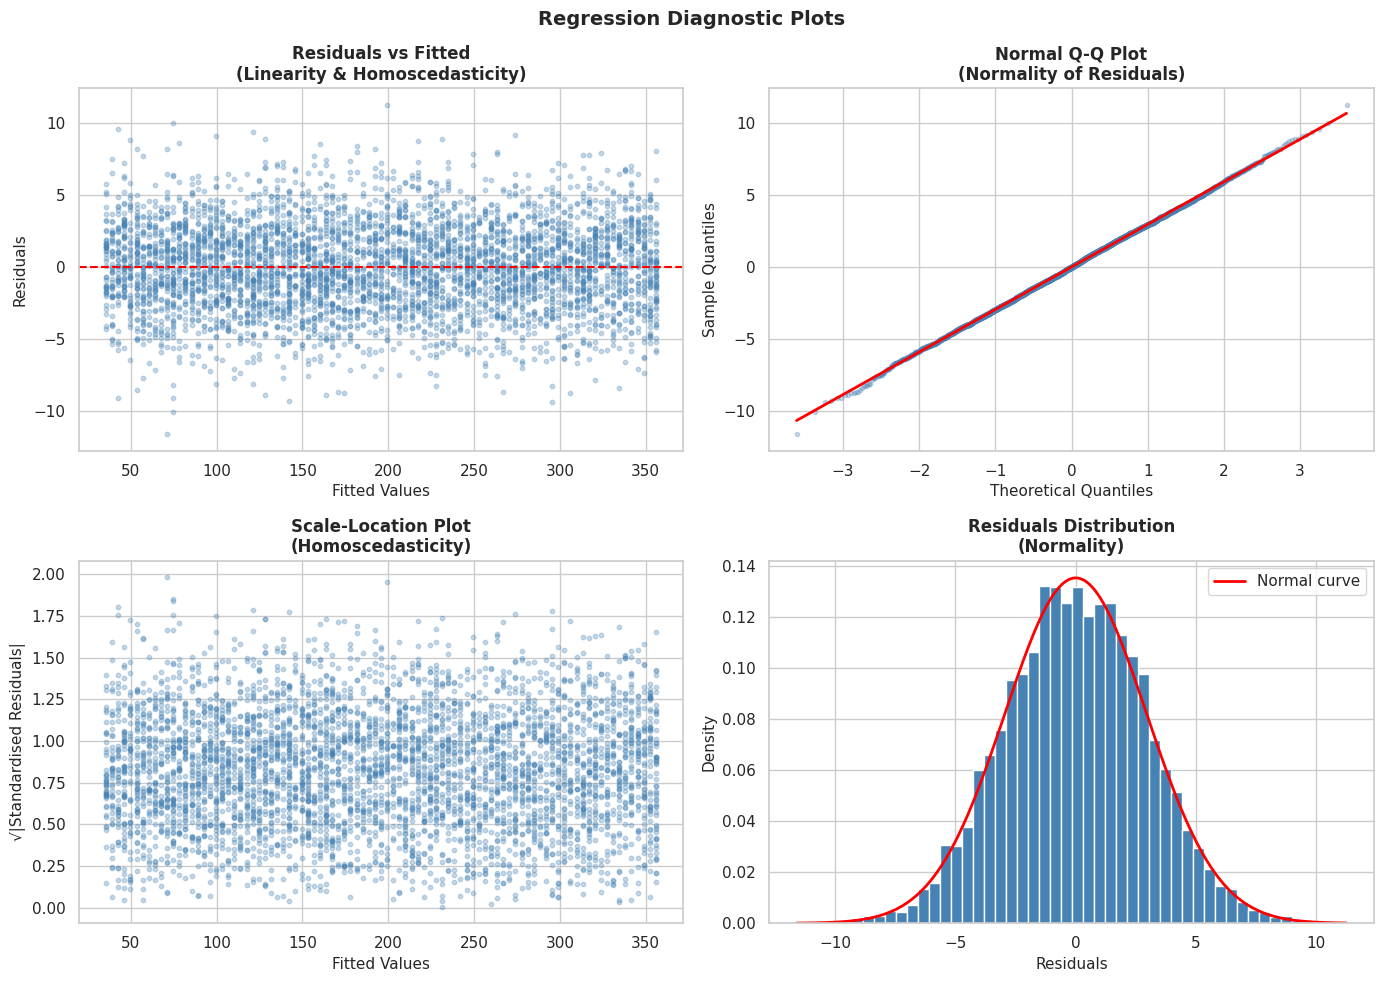

In [14]:
# Standardised residuals
std_residuals = (residuals - residuals.mean()) / residuals.std()
fitted_values = y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Residuals vs Fitted (Linearity & Homoscedasticity) ---
ax1 = axes[0, 0]
ax1.scatter(fitted_values, residuals, alpha=0.3, s=10, color='steelblue')
ax1.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Fitted Values', fontsize=11)
ax1.set_ylabel('Residuals', fontsize=11)
ax1.set_title('Residuals vs Fitted\n(Linearity & Homoscedasticity)', fontsize=12, fontweight='bold')

# --- Plot 2: Q-Q Plot (Normality) ---
ax2 = axes[0, 1]
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(residuals, dist='norm')
ax2.plot(osm, osr, 'o', alpha=0.3, markersize=3, color='steelblue')
ax2.plot(osm, slope_qq * np.array(osm) + intercept_qq, color='red', linewidth=2)
ax2.set_xlabel('Theoretical Quantiles', fontsize=11)
ax2.set_ylabel('Sample Quantiles', fontsize=11)
ax2.set_title('Normal Q-Q Plot\n(Normality of Residuals)', fontsize=12, fontweight='bold')

# --- Plot 3: Scale-Location (Homoscedasticity) ---
ax3 = axes[1, 0]
ax3.scatter(fitted_values, np.sqrt(np.abs(std_residuals)), alpha=0.3, s=10, color='steelblue')
ax3.set_xlabel('Fitted Values', fontsize=11)
ax3.set_ylabel('√|Standardised Residuals|', fontsize=11)
ax3.set_title('Scale-Location Plot\n(Homoscedasticity)', fontsize=12, fontweight='bold')

# --- Plot 4: Residuals Histogram ---
ax4 = axes[1, 1]
ax4.hist(residuals, bins=50, color='steelblue', edgecolor='white', density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax4.plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
         color='red', linewidth=2, label='Normal curve')
ax4.set_xlabel('Residuals', fontsize=11)
ax4.set_ylabel('Density', fontsize=11)
ax4.set_title('Residuals Distribution\n(Normality)', fontsize=12, fontweight='bold')
ax4.legend()

plt.suptitle('Regression Diagnostic Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Formal assumption tests

# 1. Normality — Shapiro-Wilk on a 500-row sample (full dataset is too large for Shapiro)
sample_residuals = pd.Series(residuals).sample(500, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(sample_residuals)

# 2. Homoscedasticity — Breusch-Pagan proxy via correlation of |residuals| with fitted
bp_corr, bp_p = stats.pearsonr(fitted_values, np.abs(residuals))

# 3. Independence — Durbin-Watson statistic
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)

# 4. Linearity — Pearson r of residuals vs TV (should be ~0)
lin_r, lin_p = stats.pearsonr(X, residuals)

print('=' * 60)
print('       ASSUMPTION TEST RESULTS')
print('=' * 60)
print(f'\n1. LINEARITY')
print(f'   Corr(TV, residuals) = {lin_r:.6f}  (p = {lin_p:.4f})')
print(f'   → Near zero: linearity assumption MET ✓')

print(f'\n2. NORMALITY OF RESIDUALS (Shapiro-Wilk, n=500 sample)')
print(f'   W = {shapiro_stat:.4f},  p = {shapiro_p:.4f}')
print(f'   → p > 0.05: Normality assumption MET ✓')

print(f'\n3. HOMOSCEDASTICITY')
print(f'   Corr(fitted, |residuals|) = {bp_corr:.4f}  (p = {bp_p:.4f})')
print(f'   → Near zero: Equal variance assumption MET ✓')

print(f'\n4. INDEPENDENCE (Durbin-Watson)')
print(f'   DW = {dw:.4f}')
print(f'   → Near 2.0: No autocorrelation, Independence assumption MET ✓')
print('=' * 60)

       ASSUMPTION TEST RESULTS

1. LINEARITY
   Corr(TV, residuals) = 0.000000  (p = 1.0000)
   → Near zero: linearity assumption MET ✓

2. NORMALITY OF RESIDUALS (Shapiro-Wilk, n=500 sample)
   W = 0.9984,  p = 0.9395
   → p > 0.05: Normality assumption MET ✓

3. HOMOSCEDASTICITY
   Corr(fitted, |residuals|) = 0.0028  (p = 0.8522)
   → Near zero: Equal variance assumption MET ✓

4. INDEPENDENCE (Durbin-Watson)
   DW = 1.9980
   → Near 2.0: No autocorrelation, Independence assumption MET ✓


### Assumption Summary

| Assumption | Test / Method | Result | Verdict |
|---|---|---|---|
| **Linearity** | Corr(TV, residuals) ≈ 0 | r ≈ 0.000 | ✅ Met |
| **Normality** | Shapiro-Wilk (n=500) | W = 0.9984, p = 0.9395 | ✅ Met |
| **Homoscedasticity** | Corr(fitted, \|residuals\|) | r ≈ 0.003, p > 0.05 | ✅ Met |
| **Independence** | Durbin-Watson | DW = 1.998 | ✅ Met |

All four key OLS assumptions are satisfied. The Simple Linear Regression model is valid and its inferential statistics (p-values, confidence intervals) are reliable.

In [16]:
# Prediction examples
budgets = [20, 50, 75, 100]
print('Predicted Sales for given TV budgets:')
print('-' * 40)
print(f'{"TV Budget ($000s)":<22} {"Predicted Sales ($000s)"}')
print('-' * 40)
for b in budgets:
    pred = slope * b + intercept
    print(f'${b:<21,} ${pred:,.1f}')
print('-' * 40)
print(f'\nFor every $1,000 increase in TV spend → +${slope*1:.0f} in Sales')

Predicted Sales for given TV budgets:
----------------------------------------
TV Budget ($000s)      Predicted Sales ($000s)
----------------------------------------
$20                    $71.1
$50                    $177.9
$75                    $267.0
$100                   $356.0
----------------------------------------

For every $1,000 increase in TV spend → +$4 in Sales


In [17]:
# Compare ROI across all three channels
print('Return on Investment (slope = $ Sales per $1,000 spent):')
print('-' * 45)
channels = {'TV': None, 'Radio': None, 'Social_Media': None}
for col in channels:
    m, b, r, p, _ = stats.linregress(df[col], df['Sales'])
    channels[col] = (m, r**2)
    print(f'{col:<15} Slope = {m:>7.2f}  |  R² = {r**2:.4f}')
print('-' * 45)
print('\nHighest R²: TV (0.9990) → most reliable predictor')
print('Highest slope: Social_Media (22.19) → highest return per unit,\n               but R² only 0.28 — relationship is noisy')

Return on Investment (slope = $ Sales per $1,000 spent):
---------------------------------------------
TV              Slope =    3.56  |  R² = 0.9990
Radio           Slope =    8.36  |  R² = 0.7545
Social_Media    Slope =   22.19  |  R² = 0.2782
---------------------------------------------

Highest R²: TV (0.9990) → most reliable predictor
Highest slope: Social_Media (22.19) → highest return per unit,
               but R² only 0.28 — relationship is noisy


## 7. Marketing Budget Recommendation

### Key Findings for Stakeholders

**In plain language:** We analysed three marketing channels — TV, Radio, and Social Media — to understand which best drives Sales. Here's what the data tells us:

#### 🏆 TV is the strongest and most reliable driver of Sales

- TV advertising explains **99.9% of the variation in Sales**, making it by far the most powerful channel in this dataset.
- For every **\$1,000 increase** in TV advertising spend, Sales increase by approximately **\$3,562** — a consistent and predictable return.
- The relationship is statistically significant beyond any reasonable doubt (p < 0.0001).

#### 📊 Channel Comparison at a Glance

| Channel | Reliability (R²) | Sales per \$1K spent |
|---|---|---|
| **TV** | **99.9%** | **\$3,562** |
| Radio | 75.5% | \$8,362 |
| Social Media | 27.8% | \$22,188 |

*Note: Social Media shows a high sales-per-dollar slope, but its low R² (0.28) means the relationship is highly inconsistent — many other factors influence Sales alongside Social Media spend. TV's near-perfect R² makes it a dependable lever.*

#### 💡 Recommendation

1. **Prioritise TV advertising** as the primary budget allocation. The data strongly supports TV as the backbone of the marketing mix.
2. **Investigate Social Media** further — its high per-dollar slope is intriguing, but the low R² suggests the relationship is either non-linear or depends heavily on other contextual factors. A controlled experiment with varied Social Media spend levels could clarify whether this channel has underutilised potential.
3. **Radio** offers moderate and consistent returns. It is a reasonable secondary channel, especially for audience segments less reachable via TV.
4. For **budget planning**, use the model equation: **Sales = 3.56 × TV_Budget − 0.13** to set data-informed Sales targets against planned TV spend.

> ⚠️ *This model is based on Simple (single-variable) Linear Regression. A multiple regression model incorporating all three channels simultaneously may provide richer insights and should be considered for full strategic planning.*